<a href="https://colab.research.google.com/github/Abeldb11/LLM_opt/blob/main/KD_N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers datasets accelerate evaluate scikit-learn

In [2]:
import os, time, copy, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer,
    GPT2LMHeadModel,
    GPT2ForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)
import datasets
datasets.config.TORCHVISION_AVAILABLE = False
from datasets import load_dataset

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [3]:
TEACHER_NAME = "gpt2-medium"  # 355M
STUDENT_NAME = "gpt2"          # 124M

tokenizer = AutoTokenizer.from_pretrained(STUDENT_NAME)
tokenizer.pad_token = tokenizer.eos_token

teacher_lm_model = GPT2LMHeadModel.from_pretrained(TEACHER_NAME).to(DEVICE)
teacher_lm_model.eval()
for p in teacher_lm_model.parameters():
    p.requires_grad = False


def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


teacher_total, _ = count_params(teacher_lm_model)
print(f"Teacher (GPT-2 medium) params: {teacher_total:,}")

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Teacher (GPT-2 medium) params: 354,823,168


In [4]:
#datasets
wikitext = load_dataset("salesforce/wikitext", "wikitext-2-raw-v1")
wikitext_test = wikitext["test"].filter(lambda x: len(x["text"].strip()) > 0)
wikitext_train = wikitext["train"].filter(lambda x: len(x["text"].strip()) > 0)

In [5]:
from datasets import load_dataset

sst2 = load_dataset("nyu-mll/glue", "sst2")

train_subset = sst2["train"].shuffle(seed=SEED).select(range(4000))
val_subset = sst2["validation"]


def tokenize_sst2(examples):
    return tokenizer(examples["sentence"], truncation=True, max_length=128)


train_tok = train_subset.map(tokenize_sst2, batched=True)
val_tok = val_subset.map(tokenize_sst2, batched=True)

train_tok = train_tok.rename_column("label", "labels")
val_tok = val_tok.rename_column("label", "labels")
train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

In [6]:
# evaluation utilities

@torch.no_grad()
def compute_perplexity(model, tokenizer, text_dataset, stride=512, max_length=1024):
    model.eval()
    text = "\n\n".join(text_dataset["text"])
    encodings = tokenizer(text, return_tensors="pt")
    input_ids = encodings.input_ids

    seq_len = input_ids.size(1)
    nlls = []
    prev_end = 0
    for begin in range(0, seq_len, stride):
        end = min(begin + max_length, seq_len)
        trg_len = end - prev_end
        ids = input_ids[:, begin:end].to(DEVICE)
        target_ids = ids.clone()
        target_ids[:, :-trg_len] = -100

        outputs = model(ids, labels=target_ids)
        nlls.append(outputs.loss * trg_len)

        prev_end = end
        if end == seq_len:
            break

    ppl = torch.exp(torch.stack(nlls).sum() / prev_end)
    return ppl.item()


def measure_memory(model, tokenizer, seq_len=128, batch_size=8):
    model.eval()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    dummy = torch.randint(0, tokenizer.vocab_size, (batch_size, seq_len)).to(DEVICE)
    with torch.no_grad():
        model(dummy)

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
        return torch.cuda.max_memory_allocated() / 1024**2
    return float("nan")


def measure_latency(model, tokenizer, seq_len=128, batch_size=8, n_warmup=5, n_iters=30):
    model.eval()
    dummy = torch.randint(0, tokenizer.vocab_size, (batch_size, seq_len)).to(DEVICE)

    with torch.no_grad():
        for _ in range(n_warmup):
            model(dummy)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        times = []
        for _ in range(n_iters):
            start = time.perf_counter()
            model(dummy)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            times.append((time.perf_counter() - start) * 1000)

    return float(np.mean(times)), float(np.std(times))


def ffn_flops_per_token(d_model, d_ff, active_experts=1):
    return active_experts * 2 * (2 * d_model * d_ff)


def estimate_total_flops(model, seq_len=128, moe_info=None):
    config = model.config
    d_model = config.n_embd
    d_ff = config.n_inner if config.n_inner is not None else 4 * d_model
    n_layer = config.n_layer

    attn_flops = n_layer * (4 * seq_len * d_model**2 + 2 * seq_len**2 * d_model)

    if moe_info is None:
        ffn_flops = n_layer * seq_len * ffn_flops_per_token(d_model, d_ff)
    else:
        active = moe_info["top_k"]
        ffn_flops = n_layer * seq_len * ffn_flops_per_token(d_model, d_ff, active_experts=active)

    return attn_flops + ffn_flops

In [7]:
# distillation loss
def distillation_loss(student_logits, teacher_logits, labels, temperature=2.0, alpha=0.5):
    student_log_probs = F.log_softmax(student_logits / temperature, dim=-1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=-1)
    soft_loss = F.kl_div(student_log_probs, teacher_probs, reduction="batchmean") * (temperature ** 2)

    hard_loss = F.cross_entropy(student_logits, labels)

    return alpha * soft_loss + (1 - alpha) * hard_loss

In [8]:
#baseline student
def train_classifier(model, train_dataset, val_dataset, epochs=1, lr=2e-5):
    args = TrainingArguments(
        output_dir="./clf_out",
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=epochs,
        learning_rate=lr,
        logging_steps=50,
        save_strategy="no",
        report_to="none",
        fp16=torch.cuda.is_available(),
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {"accuracy": (preds == labels).mean()}

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    eval_result = trainer.evaluate()
    return model, eval_result["eval_accuracy"]

In [10]:
results = {"baseline": {}, "distilled": {}}

print("Evaluating BASELINE student (no distillation)...")
baseline_student_lm = GPT2LMHeadModel.from_pretrained(STUDENT_NAME).to(DEVICE)
baseline_params, _ = count_params(baseline_student_lm)

results["baseline"]["params"] = baseline_params
results["baseline"]["perplexity"] = compute_perplexity(baseline_student_lm, tokenizer, wikitext_test)
results["baseline"]["memory_mb"] = measure_memory(baseline_student_lm, tokenizer)
lat_mean, lat_std = measure_latency(baseline_student_lm, tokenizer)
results["baseline"]["latency_ms"] = lat_mean
results["baseline"]["latency_std"] = lat_std
results["baseline"]["flops_per_seq"] = estimate_total_flops(baseline_student_lm, seq_len=128)

print("Fine-tuning BASELINE classifier (hard labels only)...")
baseline_clf = GPT2ForSequenceClassification.from_pretrained(
    STUDENT_NAME, num_labels=2, pad_token_id=tokenizer.pad_token_id
).to(DEVICE)
baseline_clf, baseline_acc = train_classifier(baseline_clf, train_tok, val_tok, epochs=1)
results["baseline"]["accuracy"] = baseline_acc

print(json.dumps(results, indent=2))

Evaluating BASELINE student (no distillation)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Fine-tuning BASELINE classifier (hard labels only)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,1.061222
100,0.661692
150,0.485538
200,0.426715
250,0.401297


Training Loss,Validation Loss,Step,Accuracy
0.401297,0.324730,250,0.870413


{
  "baseline": {
    "params": 124439808,
    "perplexity": 24.356857299804688,
    "memory_mb": 2855.38232421875,
    "latency_ms": 96.42727163332741,
    "latency_std": 0.8975815621860147,
    "flops_per_seq": 18421383168,
    "accuracy": 0.8704128440366973
  },
  "distilled": {}
}


In [11]:
#train the teacher classifier
print("Fine-tuning TEACHER classifier (GPT-2 medium) on SST-2...")
teacher_clf = GPT2ForSequenceClassification.from_pretrained(
    TEACHER_NAME, num_labels=2, pad_token_id=tokenizer.pad_token_id
).to(DEVICE)
teacher_clf, teacher_clf_acc = train_classifier(teacher_clf, train_tok, val_tok, epochs=1)
teacher_clf.eval()
for p in teacher_clf.parameters():
    p.requires_grad = False

print(f"Teacher classifier accuracy: {teacher_clf_acc:.4f}")

Fine-tuning TEACHER classifier (GPT-2 medium) on SST-2...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2-medium
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,1.484886
100,0.404914
150,0.360914
200,0.329150
250,0.288231


Training Loss,Validation Loss,Step,Accuracy
0.288231,0.247704,250,0.899083


Teacher classifier accuracy: 0.8991


In [13]:
# distillation of the teacher

def prepare_lm_dataset(dataset, tokenizer, block_size=512):
    def tokenize_fn(examples):
        return tokenizer(examples["text"],
                         return_attention_mask=False,)

    tokenized = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

    def group_texts(examples):
        concatenated = sum(examples["input_ids"], [])
        total_len = (len(concatenated) // block_size) * block_size
        result = {"input_ids": [concatenated[i:i + block_size] for i in range(0, total_len, block_size)]}
        result["labels"] = result["input_ids"].copy()
        return result

    lm_dataset = tokenized.map(group_texts, batched=True)
    lm_dataset.set_format(type="torch", columns=["input_ids", "labels"])
    return lm_dataset


def get_shifted_logits_labels(logits, labels):
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = labels[..., 1:].contiguous()
    return shift_logits, shift_labels


def distill_lm(teacher_model, student_model, lm_dataset, steps=300, batch_size=4,
                lr=5e-5, temperature=2.0, alpha=0.5):
    teacher_model.eval()
    student_model.train()

    loader = DataLoader(lm_dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(student_model.parameters(), lr=lr)

    step = 0
    losses = []
    for batch in loader:
        if step >= steps:
            break
        input_ids = batch["input_ids"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        with torch.no_grad():
            teacher_logits = teacher_model(input_ids).logits

        student_logits = student_model(input_ids).logits

        s_logits, s_labels = get_shifted_logits_labels(student_logits, labels)
        t_logits, _ = get_shifted_logits_labels(teacher_logits, labels)

        vocab_size = s_logits.size(-1)
        s_logits = s_logits.reshape(-1, vocab_size)
        t_logits = t_logits.reshape(-1, vocab_size)
        s_labels = s_labels.reshape(-1)

        loss = distillation_loss(s_logits, t_logits, s_labels, temperature=temperature, alpha=alpha)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        losses.append(loss.item())
        step += 1
        if step % 50 == 0:
            print(f"step {step}/{steps} - loss {loss.item():.4f}")

    student_model.eval()
    return losses


lm_train_dataset = prepare_lm_dataset(wikitext_train, tokenizer, block_size=512)

print("Distilling GPT-2 medium -> GPT-2 small on WikiText-2...")
distilled_lm_model = GPT2LMHeadModel.from_pretrained(STUDENT_NAME).to(DEVICE)  # fresh student copy
lm_distill_losses = distill_lm(
    teacher_lm_model, distilled_lm_model, lm_train_dataset,
    steps=300, batch_size=4, lr=5e-5, temperature=2.0, alpha=0.5,
)

Map:   0%|          | 0/23767 [00:00<?, ? examples/s]

Map:   0%|          | 0/23767 [00:00<?, ? examples/s]

Distilling GPT-2 medium -> GPT-2 small on WikiText-2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

step 50/300 - loss 2.2690
step 100/300 - loss 2.1785
step 150/300 - loss 2.2884
step 200/300 - loss 2.2238
step 250/300 - loss 2.2568
step 300/300 - loss 2.1340


In [14]:
# distillation classification
def distill_classifier(teacher_clf, student_clf, train_dataset, steps=250, batch_size=16,
                        lr=2e-5, temperature=2.0, alpha=0.5):
    teacher_clf.eval()
    student_clf.train()

    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=data_collator)
    optimizer = torch.optim.AdamW(student_clf.parameters(), lr=lr)

    step = 0
    losses = []
    for batch in loader:
        if step >= steps:
            break
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        with torch.no_grad():
            teacher_logits = teacher_clf(input_ids=input_ids, attention_mask=attention_mask).logits

        student_logits = student_clf(input_ids=input_ids, attention_mask=attention_mask).logits

        loss = distillation_loss(student_logits, teacher_logits, labels, temperature=temperature, alpha=alpha)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        losses.append(loss.item())
        step += 1
        if step % 50 == 0:
            print(f"step {step}/{steps} - loss {loss.item():.4f}")

    student_clf.eval()
    return losses


print("Distilling teacher classifier -> fresh GPT-2 small classifier on SST-2...")
distilled_clf = GPT2ForSequenceClassification.from_pretrained(
    STUDENT_NAME, num_labels=2, pad_token_id=tokenizer.pad_token_id
).to(DEVICE)
clf_distill_losses = distill_classifier(
    teacher_clf, distilled_clf, train_tok,
    steps=250, batch_size=16, lr=2e-5, temperature=2.0, alpha=0.5,
)


@torch.no_grad()
def evaluate_classifier_accuracy(model, val_dataset, batch_size=32):
    model.eval()
    loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=data_collator)
    correct, total = 0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total


distilled_clf_acc = evaluate_classifier_accuracy(distilled_clf, val_tok)
print(f"Distilled classifier accuracy: {distilled_clf_acc:.4f}")

Distilling teacher classifier -> fresh GPT-2 small classifier on SST-2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


step 50/250 - loss 0.6811
step 100/250 - loss 0.2888
step 150/250 - loss 0.3462
step 200/250 - loss 0.2501
step 250/250 - loss 0.3814
Distilled classifier accuracy: 0.8830


In [15]:
#evaluate the distilled model

print("Evaluating DISTILLED student...")
distilled_params, _ = count_params(distilled_lm_model)

results["distilled"]["params"] = distilled_params
results["distilled"]["perplexity"] = compute_perplexity(distilled_lm_model, tokenizer, wikitext_test)
results["distilled"]["memory_mb"] = measure_memory(distilled_lm_model, tokenizer)
lat_mean, lat_std = measure_latency(distilled_lm_model, tokenizer)
results["distilled"]["latency_ms"] = lat_mean
results["distilled"]["latency_std"] = lat_std
results["distilled"]["flops_per_seq"] = estimate_total_flops(distilled_lm_model, seq_len=128)
results["distilled"]["accuracy"] = distilled_clf_acc

print(json.dumps(results, indent=2))

Evaluating DISTILLED student...
{
  "baseline": {
    "params": 124439808,
    "perplexity": 24.356857299804688,
    "memory_mb": 2855.38232421875,
    "latency_ms": 96.42727163332741,
    "latency_std": 0.8975815621860147,
    "flops_per_seq": 18421383168,
    "accuracy": 0.8704128440366973
  },
  "distilled": {
    "params": 124439808,
    "perplexity": 20.690759658813477,
    "memory_mb": 5665.92041015625,
    "latency_ms": 92.88866529999116,
    "latency_std": 1.1297455218784411,
    "flops_per_seq": 18421383168,
    "accuracy": 0.8830275229357798
  }
}


In [16]:
# comparison table
df = pd.DataFrame(results).T
df = df[["params", "accuracy", "perplexity", "memory_mb", "latency_ms", "flops_per_seq"]]
df.columns = ["Params", "Accuracy", "Perplexity", "Peak Memory (MB)", "Latency (ms)", "FLOPs/seq"]
display(df)

df.to_csv("kd_comparison_results.csv")
with open("kd_results.json", "w") as f:
    json.dump(results, f, indent=2)

,Params,Accuracy,Perplexity,Peak Memory (MB),Latency (ms),FLOPs/seq
baseline,124439808.0,0.870413,24.356857,2855.382324,96.427272,1.842138e+10
distilled,124439808.0,0.883028,20.690760,5665.920410,92.888665,1.842138e+10


In [17]:
#plot
df = pd.DataFrame(results).T
df = df[["params", "accuracy", "perplexity", "memory_mb", "latency_ms", "flops_per_seq"]]
df.columns = ["Params", "Accuracy", "Perplexity", "Peak Memory (MB)", "Latency (ms)", "FLOPs/seq"]
display(df)

df.to_csv("kd_comparison_results.csv")
with open("kd_results.json", "w") as f:
    json.dump(results, f, indent=2)

,Params,Accuracy,Perplexity,Peak Memory (MB),Latency (ms),FLOPs/seq
baseline,124439808.0,0.870413,24.356857,2855.382324,96.427272,1.842138e+10
distilled,124439808.0,0.883028,20.690760,5665.920410,92.888665,1.842138e+10


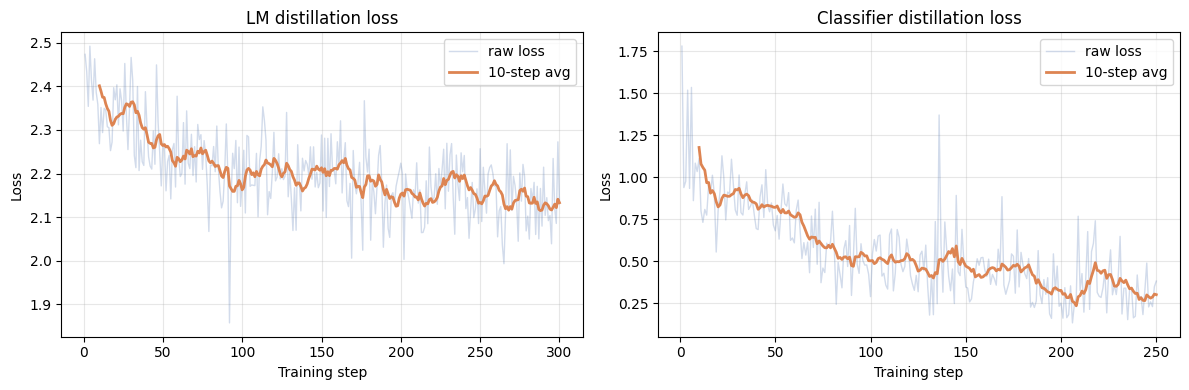

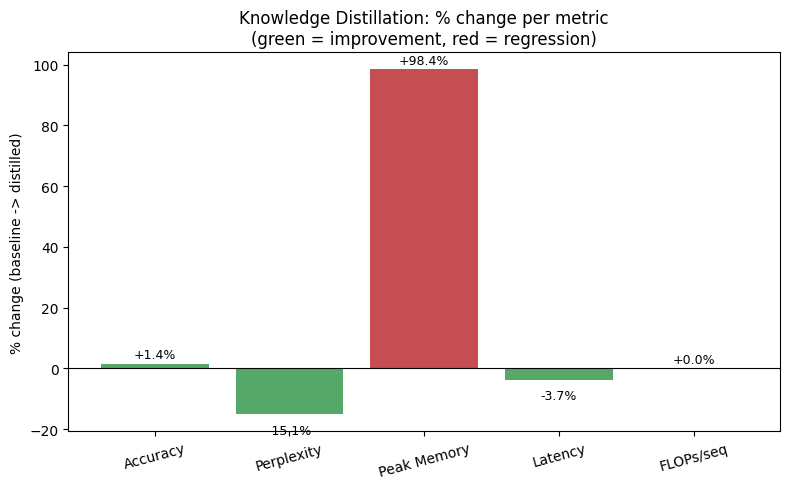

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Training loss curves (raw + smoothed) for both distillation runs
def plot_training_curves(loss_dict, window=10, figsize=(12, 4)):
    n = len(loss_dict)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]

    for ax, (name, losses) in zip(axes, loss_dict.items()):
        losses = np.array(losses)
        steps = np.arange(1, len(losses) + 1)
        ax.plot(steps, losses, color="#4C72B0", alpha=0.25, linewidth=1, label="raw loss")

        if len(losses) >= window:
            smoothed = np.convolve(losses, np.ones(window) / window, mode="valid")
            ax.plot(steps[window - 1:], smoothed, color="#DD8452", linewidth=2, label=f"{window}-step avg")

        ax.set_title(f"{name} loss")
        ax.set_xlabel("Training step")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("kd_training_curves.png", dpi=150)
    plt.show()


plot_training_curves({
    "LM distillation": lm_distill_losses,
    "Classifier distillation": clf_distill_losses,
})


# 2. % change per metric, color-coded improvement (green) vs regression (red)
def plot_percent_change(results, baseline_key="baseline", after_key="distilled", figsize=(8, 5)):
    higher_is_better = {"accuracy": True, "perplexity": False, "memory_mb": False,
                         "latency_ms": False, "flops_per_seq": False}
    labels = {"accuracy": "Accuracy", "perplexity": "Perplexity", "memory_mb": "Peak Memory",
              "latency_ms": "Latency", "flops_per_seq": "FLOPs/seq"}

    metrics = list(higher_is_better.keys())
    pct_changes, colors = [], []
    for m in metrics:
        before, after = results[baseline_key][m], results[after_key][m]
        pct = (after - before) / before * 100
        pct_changes.append(pct)
        is_good = (pct > 0) if higher_is_better[m] else (pct < 0)
        colors.append("#55A868" if is_good else "#C44E52")

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar([labels[m] for m in metrics], pct_changes, color=colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("% change (baseline -> distilled)")
    ax.set_title("Knowledge Distillation: % change per metric\n(green = improvement, red = regression)")

    for bar, pct in zip(bars, pct_changes):
        y = bar.get_height()
        ax.annotate(f"{pct:+.1f}%", (bar.get_x() + bar.get_width() / 2, y),
                    textcoords="offset points", xytext=(0, 4 if y >= 0 else -14),
                    ha="center", fontsize=9)

    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig("kd_percent_change.png", dpi=150)
    plt.show()


plot_percent_change(results)


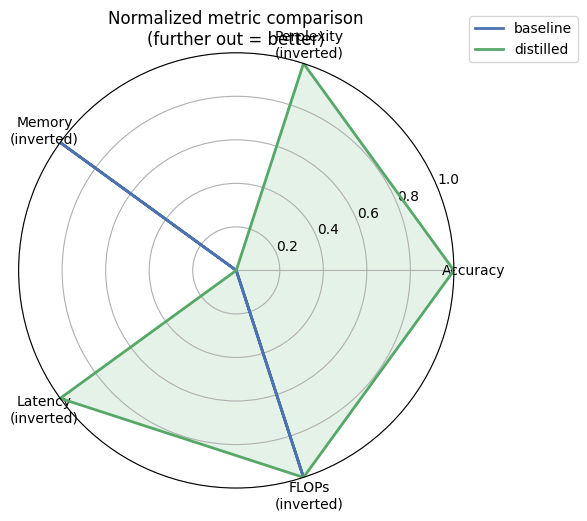

In [22]:
# 3. Radar chart: normalized multi-metric comparison (works for 2-way or 3-way incl. MoE)
def plot_radar_comparison(results, keys=("baseline", "distilled"), figsize=(6, 6)):
    metrics = ["accuracy", "perplexity", "memory_mb", "latency_ms", "flops_per_seq"]
    labels = ["Accuracy", "Perplexity\n(inverted)", "Memory\n(inverted)",
              "Latency\n(inverted)", "FLOPs\n(inverted)"]
    higher_is_better = [True, False, False, False, False]

    raw = {k: [results[k][m] for m in metrics] for k in keys}
    normalized = {k: [] for k in keys}
    for i, m in enumerate(metrics):
        values = [raw[k][i] for k in keys]
        lo, hi = min(values), max(values)
        for k in keys:
            v = raw[k][i]
            score = 1.0 if hi == lo else (v - lo) / (hi - lo)
            if hi != lo and not higher_is_better[i]:
                score = 1 - score
            normalized[k].append(score)

    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))
    colors = {"baseline": "#4C72B0", "distilled": "#55A868", "moe": "#DD8452"}

    for k in keys:
        values = normalized[k] + normalized[k][:1]
        ax.plot(angles, values, label=k, color=colors.get(k), linewidth=2)
        ax.fill(angles, values, color=colors.get(k), alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)
    ax.set_title("Normalized metric comparison\n(further out = better)")
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.savefig("kd_radar_comparison.png", dpi=150)
    plt.show()


plot_radar_comparison(results, keys=("baseline", "distilled"))